<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_04_Deep_Learning/Week_01_Foundation_on_DL/Day_03_Multilayer_Perceptron_FP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("/content/Churn_Modelling.csv")

In [31]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [33]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [36]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [37]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [38]:
df.drop(columns=['RowNumber','CustomerId','Surname'])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [60]:
pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state =1)

In [62]:
x_train.shape,x_test.shape

((8000, 11), (2000, 11))

In [63]:
y_train.shape,y_test.shape

((8000,), (2000,))

In [64]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [65]:
x_train_scaled = scaler.fit_transform(x_train)

In [67]:
x_test_scaled = scaler.transform(x_test)

In [78]:
x_test_scaled.shape, x_train_scaled.shape

((2000, 11), (8000, 11))

In [70]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [71]:
Model = Sequential()

In [91]:
Model.add(Dense(3,activation='sigmoid',input_dim=11))
Model.add(Dense(1,activation='sigmoid'))



In [74]:
Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [82]:
Model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [92]:
Model.fit(x_train_scaled, y_train, epochs= 40, validation_split =0.2)

Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8560 - loss: 0.3539 - val_accuracy: 0.8525 - val_loss: 0.3575
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8529 - loss: 0.3644 - val_accuracy: 0.8519 - val_loss: 0.3576
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8589 - loss: 0.3492 - val_accuracy: 0.8525 - val_loss: 0.3572
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8518 - loss: 0.3547 - val_accuracy: 0.8531 - val_loss: 0.3573
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8515 - loss: 0.3592 - val_accuracy: 0.8506 - val_loss: 0.3577
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - loss: 0.3539 - val_accuracy: 0.8525 - val_loss: 0.3574
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8615 - loss: 0.3474 - val_accuracy: 0.8525 - val_loss: 0.3573
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8584 - loss: 0.3558 - val_accuracy: 0.

In [93]:
Model.layers[0].get_weights()

[array([[ 0.15904012, -0.01049656,  0.11364413],
        [-2.126434  , -0.55305505, -0.05802719],
        [-0.0275309 , -0.14697044,  0.02557665],
        [-0.254249  , -0.92149705,  0.5702222 ],
        [-0.5243288 , -3.958323  ,  1.2496746 ],
        [-0.00563103, -0.08559608, -0.01680704],
        [-0.65292853, -0.75144213, -0.77228206],
        [-0.01254671,  0.06988741, -0.03102631],
        [ 0.12616916,  0.7683004 , -0.09457085],
        [-0.06875236, -0.07506032,  0.0735438 ],
        [ 0.09275143, -0.07369553, -0.19860889]], dtype=float32),
 array([ 0.10849702, -2.5118873 , -1.4709432 ], dtype=float32)]

In [95]:
Model.layers[1].get_weights()

[array([[-4.364563 ],
        [ 4.810747 ],
        [ 4.8658476]], dtype=float32),
 array([-2.3677316], dtype=float32)]

In [96]:
y_log = Model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [98]:
y_pred = np.where(y_log>0.5,1,0)

In [99]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8615

In [100]:
history = Model.fit(x_train_scaled, y_train, epochs= 40, validation_split =0.2)


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8621 - loss: 0.3437 - val_accuracy: 0.8575 - val_loss: 0.3516
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.3536 - val_accuracy: 0.8562 - val_loss: 0.3515
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8583 - loss: 0.3475 - val_accuracy: 0.8562 - val_loss: 0.3516
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.3486 - val_accuracy: 0.8556 - val_loss: 0.3516
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8634 - loss: 0.3498 - val_accuracy: 0.8556 - val_loss: 0.3511
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.3518 - val_accuracy: 0.8569 - val_loss: 0.3514
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3392 - val_accuracy: 0.8575 - val_loss: 0.3507
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3435 - val_accuracy: 0.

In [102]:
history.history

{'accuracy': [0.8590624928474426,
  0.8596875071525574,
  0.8598437309265137,
  0.8595312237739563,
  0.8610937595367432,
  0.8603125214576721,
  0.8614062666893005,
  0.8607812523841858,
  0.8598437309265137,
  0.8603125214576721,
  0.8600000143051147,
  0.8614062666893005,
  0.8607812523841858,
  0.8615624904632568,
  0.8595312237739563,
  0.8607812523841858,
  0.8614062666893005,
  0.8609374761581421,
  0.8626562356948853,
  0.8614062666893005,
  0.8612499833106995,
  0.862500011920929,
  0.8620312213897705,
  0.8615624904632568,
  0.862500011920929,
  0.8618749976158142,
  0.8618749976158142,
  0.8623437285423279,
  0.8612499833106995,
  0.8614062666893005,
  0.8610937595367432,
  0.8617187738418579,
  0.8612499833106995,
  0.8617187738418579,
  0.8617187738418579,
  0.8615624904632568,
  0.8603125214576721,
  0.8614062666893005,
  0.8618749976158142,
  0.8610937595367432],
 'loss': [0.3509029448032379,
  0.35075947642326355,
  0.3505476117134094,
  0.35042858123779297,
  0.3501563

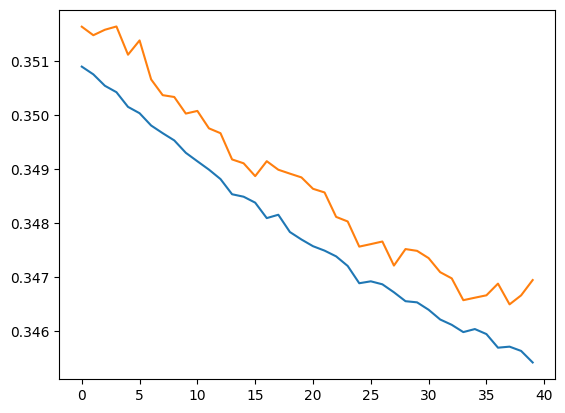

In [107]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'],label='validation')

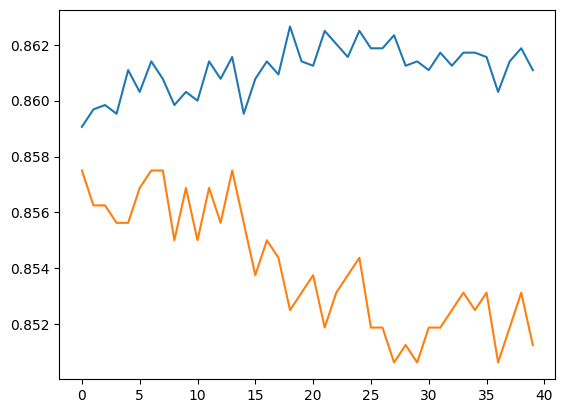

In [110]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'],label='validation')